In [ ]:
#Question 1
import pandas as pd
from scipy.stats import zscore
df=pd.read_csv("/healthcare-dataset-stroke-data.csv")
print("DATASET INFORMATION:")
df.info()
print("\nDATASET DESCRIPTION:")
df.describe()

print("\nMissing values per column:\n", df.isnull().sum())

#Question 2

print("\nPercentage of missing values per column:\n", (df.isnull().sum())/(df.count())*100)
print("No columns will be dropped.")

print("\nFilling missing values in 'bmi' with the median...")
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

print("Confirming no missing values in 'bmi':\n", df.isnull().sum())

#Question 3

print("\nNumber of duplicate rows:")
print(df.duplicated().sum())
df.drop_duplicates(inplace=True) # Adding inplace=True to modify the DataFrame directly
print("Removed all duplicates.")

#Question 4

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("\nCategorical columns found:")
print(categorical_cols)

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print("\nOne-Hot Encoding applied:")
display(df_encoded)

#Question 5
def iqrmethod(df ,column):
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)
  IQR = Q3 - Q1
  upperbound=Q3+1.5*IQR
  lowerbound=Q1-1.5*IQR
  outliers=[]
  for val in df[column]:
    if val > upperbound or val < lowerbound:
      outliers.append(val)
  return outliers
bmi_outliers = iqrmethod(df, 'bmi')
glucose_outliers = iqrmethod(df, 'avg_glucose_level')

print("\nNumber of outliers in 'bmi' using IQR method:")
print(len(bmi_outliers))

print("\nNumber of outliers in 'avg_glucose_level' using IQR method:")
print(len(glucose_outliers))

def zscore_outliers(df,column): # Renamed function to avoid conflict with imported zscore
  mean=df[column].mean()
  std=df[column].std()
  outliers=[]
  for val in df[column]:
    if(abs(val-mean)/std>3): # Use absolute value for z-score
      outliers.append(val)
  return outliers
bmi_zscore=zscore_outliers(df,'bmi')
glucose_zscore=zscore_outliers(df,'avg_glucose_level')

print("\nNumber of outliers in 'bmi' using Z-score method:")
print(len(bmi_zscore))

print("\nNumber of outliers in 'avg_glucose_level' using Z-score method:")
print(len(glucose_zscore))

print("\nComparison of Outlier Detection Methods:")
print(f"Total outliers found by IQR method: {len(bmi_outliers)+len(glucose_outliers)}")
print(f"Total outliers found by Z-score method: {len(bmi_zscore)+len(glucose_zscore)}")
print("IQR is often considered a better method for skewed data as it is less sensitive to extreme values compared to the Z-score method.")

DATASET INFORMATION:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB

DATASET DESCRIPTION:

Missing values per column:
 id                     0
gender                 0
age                    0
hypertensi

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Male,gender_Other,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,9046,67.0,0,1,228.69,36.6,1,True,False,True,False,True,False,False,True,True,False,False
1,51676,61.0,0,0,202.21,28.1,1,False,False,True,False,False,True,False,False,False,True,False
2,31112,80.0,0,1,105.92,32.5,1,True,False,True,False,True,False,False,False,False,True,False
3,60182,49.0,0,0,171.23,34.4,1,False,False,True,False,True,False,False,True,False,False,True
4,1665,79.0,1,0,174.12,24.0,1,False,False,True,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,80.0,1,0,83.75,28.1,0,False,False,True,False,True,False,False,True,False,True,False
5106,44873,81.0,0,0,125.20,40.0,0,False,False,True,False,False,True,False,True,False,True,False
5107,19723,35.0,0,0,82.99,30.6,0,False,False,True,False,False,True,False,False,False,True,False
5108,37544,51.0,0,0,166.29,25.6,0,True,False,True,False,True,False,False,False,True,False,False



Number of outliers in 'bmi' using IQR method:
126

Number of outliers in 'avg_glucose_level' using IQR method:
627

Number of outliers in 'bmi' using Z-score method:
59

Number of outliers in 'avg_glucose_level' using Z-score method:
49

Comparison of Outlier Detection Methods:
Total outliers found by IQR method: 753
Total outliers found by Z-score method: 108
IQR is often considered a better method for skewed data as it is less sensitive to extreme values compared to the Z-score method.


--- Dataset Information ---
Shape of the dataset: (150, 5)
Column names: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
First five rows:
    sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
---------------------------


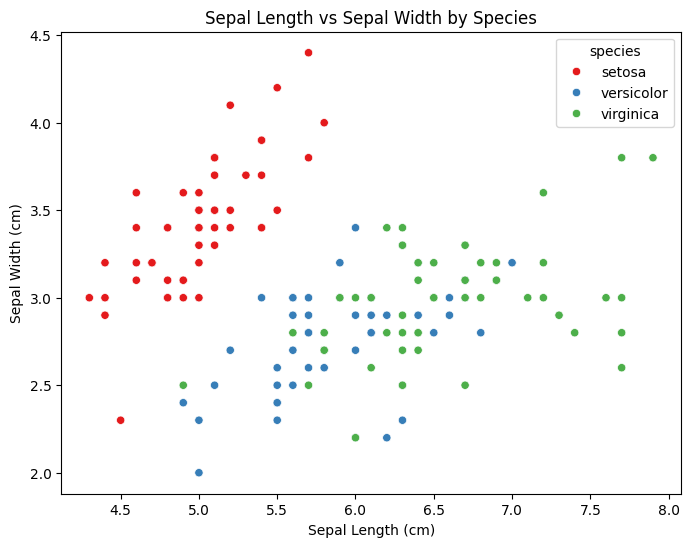

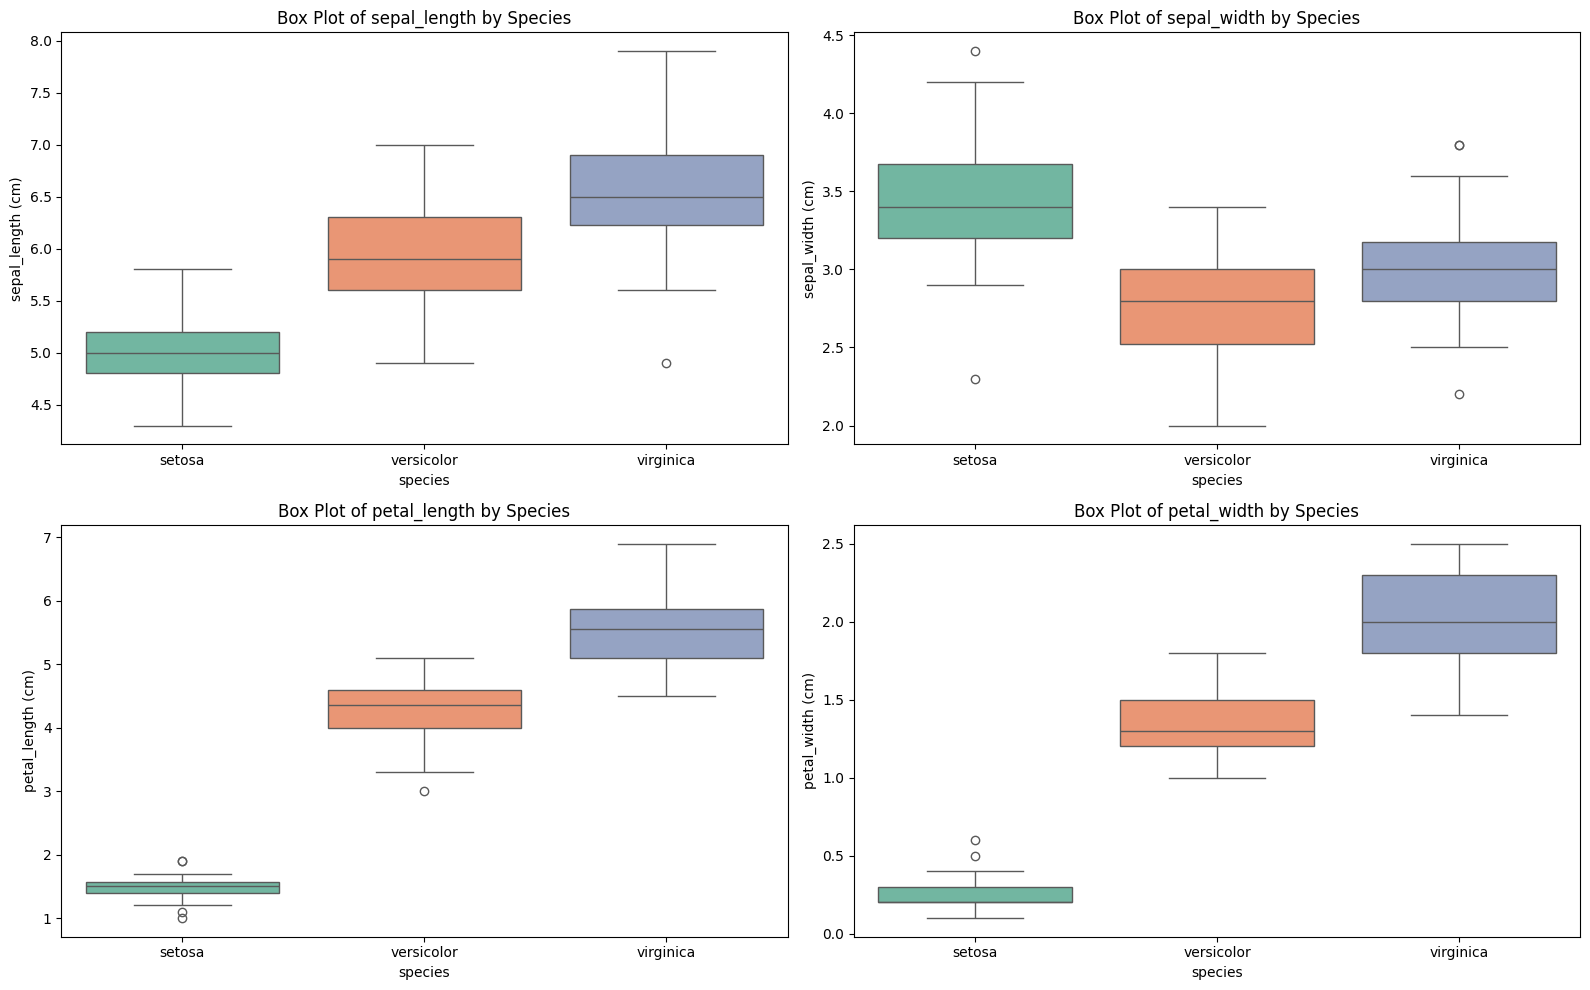

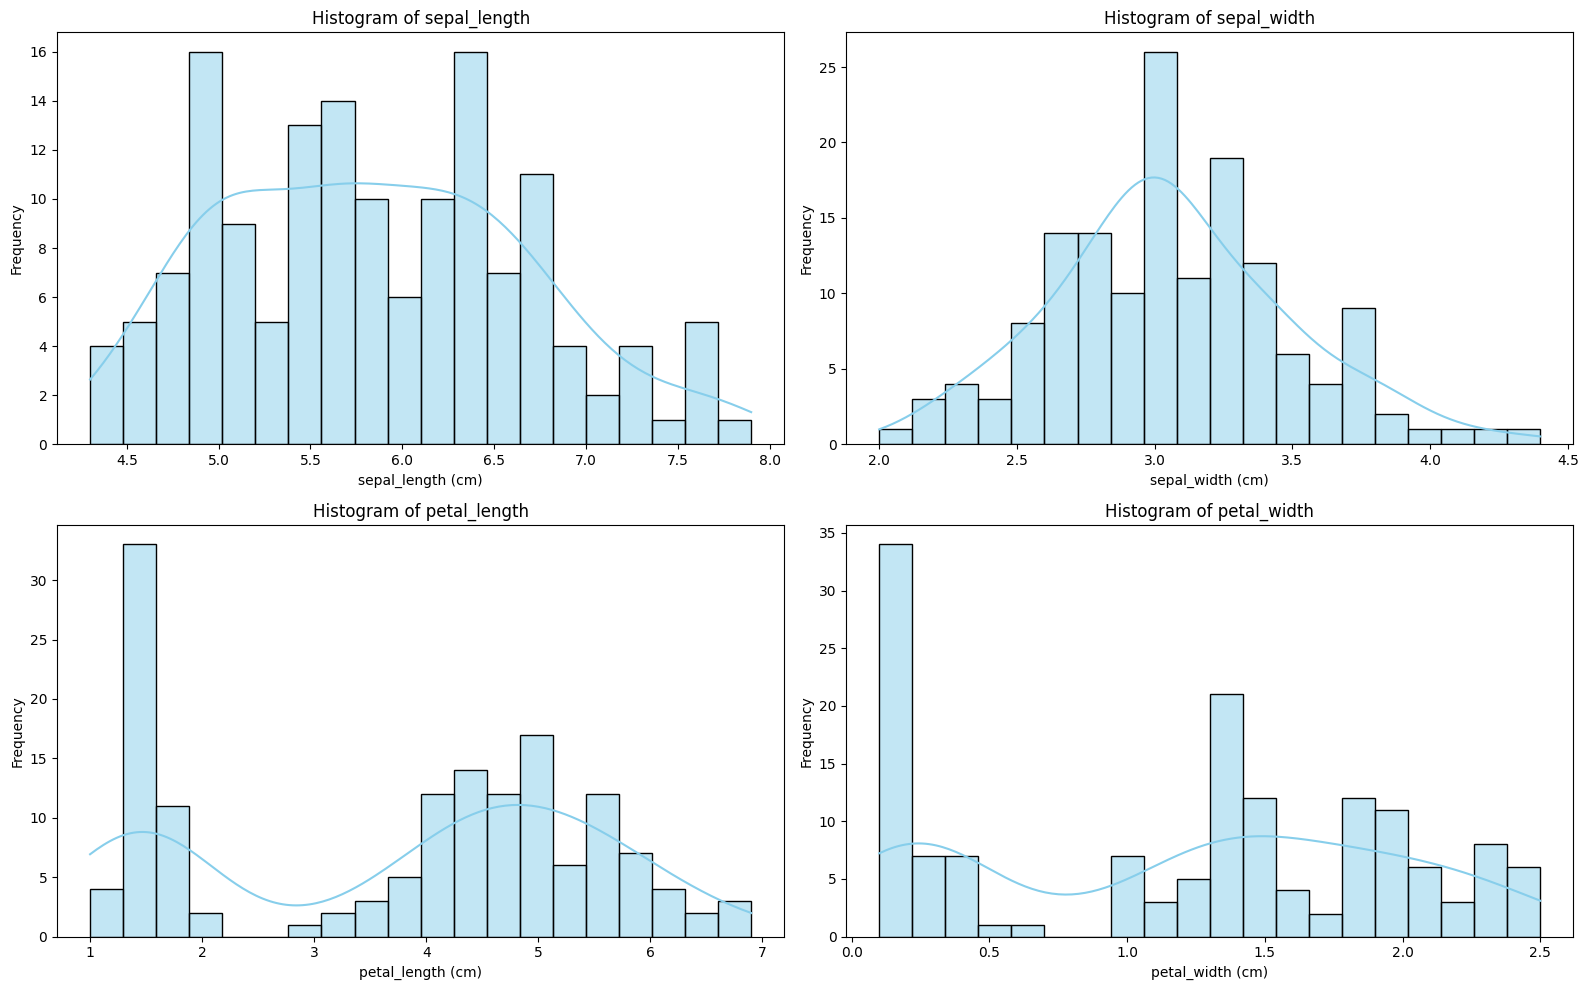

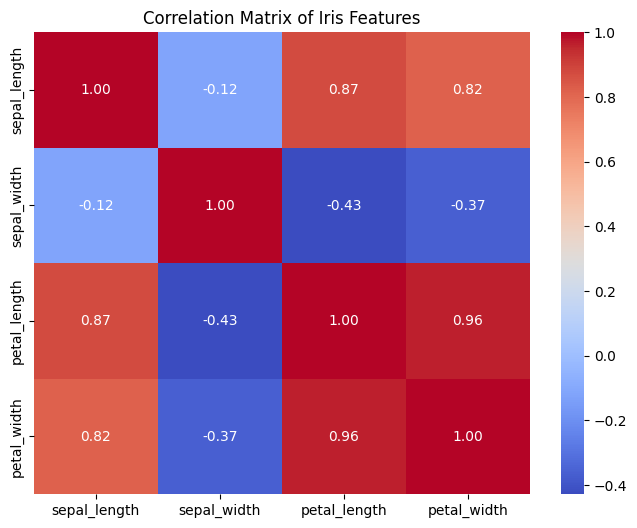

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Load the iris dataset
iris = sns.load_dataset('iris')

# Display basic information about the dataset
print("--- Dataset Information ---")
print("Shape of the dataset:", iris.shape)
print("Column names:", iris.columns.tolist())
print("First five rows:\n", iris.head())
print("---------------------------")

# Scatter plot of Sepal Length vs Sepal Width by Species
plt.figure(figsize=(8, 6))
sns.scatterplot(data=iris, x='sepal_length', y='sepal_width', hue='species', palette='Set1')
plt.title('Sepal Length vs Sepal Width by Species')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.show()

# Box plots of numerical features by Species
numeric_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
plt.figure(figsize=(16, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=iris, x='species', y=col, hue='species', palette='Set2', legend=False)
    plt.title(f'Box Plot of {col} by Species')
    plt.ylabel(f'{col} (cm)') # Added unit to y-axis label
plt.tight_layout()
plt.show()

# Histograms of numerical features
plt.figure(figsize=(16, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(data=iris, x=col, kde=True, bins=20, color='skyblue')
    plt.title(f'Histogram of {col}')
    plt.xlabel(f'{col} (cm)') # Added unit to x-axis label
    plt.ylabel('Frequency') # Added y-axis label
plt.tight_layout()
plt.show()

# Correlation matrix heatmap
corr_matrix = iris[numeric_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Iris Features')
plt.show()